In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [4]:
ws_dict = {}
for data_name in ["ERA5", "BARRA-R2"]:
    if data_name == "ERA5":
        var_name = "ws10m"
    else:
        var_name = "wss"
    
    for grid in ["NEM", "SWIS", "NWIS"]:
        
        if grid == "NEM":
            
            for scenario in ["wind_2025", "wind_2030", "wind_2040", "wind_2050"]:
                
                for subgrid in ["NEM", "SE"]:
                    
                    for unweight in [True, False]:
                        
                        fname = "grid_mean_"+var_name+"_"+data_name+"_"+grid+"_"+scenario+"_"+subgrid+"_"
                        key = data_name+"_"+grid+"_"+subgrid+"_"+scenario+"_"
                        
                        if unweight:
                            fname = fname+"unweighted"
                            key = key+"unweighted"
                        else:
                            fname = fname+"weighted"
                            key = key+"weighted"
                        
                        ws_dict[key] = xr.open_dataarray(FILEPATH+fname+".nc")
        else:
            fname = "grid_mean_"+var_name+"_"+data_name+"_"+grid
            key = data_name+"_"+grid
            
            ws_dict[key] = xr.open_dataarray(FILEPATH+fname+".nc")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [5]:
# Check size
nbytes = []
for k, v in ws_dict.items():
    nbytes.append(v.nbytes)
sum(nbytes) / 1024 ** 3

0.00450664758682251

### Wind speed statistics

In [6]:
era_nem = ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]
barra_nem = ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]

(0.0, 7.0)

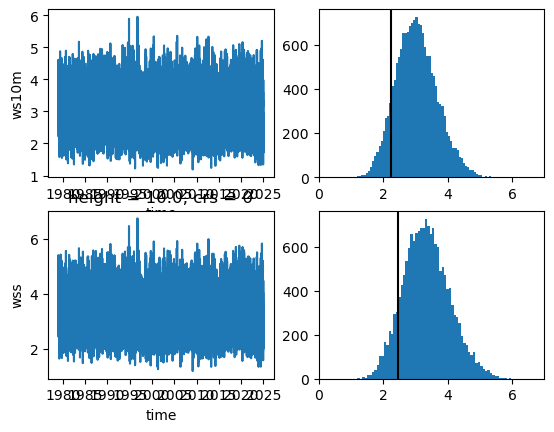

In [7]:
fig, ax = plt.subplots(2, 2)

era_nem.plot(ax=ax[0,0])
_ = ax[0,1].hist(era_nem, "fd")
ax[0,1].axvline(era_nem.quantile(0.1, "time"), c="k")
ax[0,1].set_xlim(0,7)

# da.resample(time="1YS").mean().plot(ax=ax[1,0])
# _ = ax[1,1].hist(da.resample(time="1YS").mean(), "fd")

# (da ** 3).plot(ax=ax[1,0])
# _ = ax[1,1].hist((da ** 3), "fd")
# ax[1,1].axvline((da ** 3).quantile(0.1, "time"), c="k")

barra_nem.plot(ax=ax[1,0])
_ = ax[1,1].hist(barra_nem, "fd")
ax[1,1].axvline(barra_nem.quantile(0.1, "time"), c="k")
ax[1,1].set_xlim(0,7)

### Drought definition

10th percentile, based on AEMO report for wind lulls (pg 31, Fig 41): https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf?rev=7436be91333e4603bc59158b0bf095a1&sc_lang=en&hash=A49B4BC337B25B842566B8F5EE4C8331 

In [7]:
def cumsum_reset_on_mask(data, mask, dim="time"):
    """
    Cumulative sum of `data` along `dim`, resetting to zero wherever `mask` == 0.
    
    Parameters
    ----------
    data : xr.DataArray
        Array to accumulate.
    mask : xr.DataArray
        Binary array of the same shape, where 0 means "reset".
    dim : str
        Dimension along which to accumulate (default: "time").
        
    Returns
    -------
    xr.DataArray
        Same shape as `data`, cumulative sum with resets.
    """
    a = data.values
    reset = (mask.values == 0)

    out = np.zeros_like(a, dtype=float)

    axis = data.get_axis_num(dim)
    a = np.moveaxis(a, axis, 0)
    reset = np.moveaxis(reset, axis, 0)
    out = np.moveaxis(out, axis, 0)

    acc = np.zeros_like(a[0], dtype=float)
    for i in range(a.shape[0]):
        acc = np.where(reset[i], 0, acc + a[i])
        out[i] = acc

    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=data.coords, dims=data.dims, attrs=data.attrs)


In [8]:
DROUGHT_Q = 0.1

In [9]:
for k,v in ws_dict.items():
    ws_dict[k] = v.to_dataset(name=v.name)
    ds = ws_dict[k]

    # Compute drought days and cumulative lengths
    drought_days = xr.where(v < v.quantile(DROUGHT_Q, "time"), 1, 0)
    drought_sum = cumsum_reset_on_mask(drought_days, drought_days).astype("int")

    # Accumulate wind speed anomalies over drought days
    ws_clim = v.mean("time")
    ws_anoms = v - ws_clim
    ws_severity = cumsum_reset_on_mask(ws_anoms, drought_days)
    
    # ds["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    # ds["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

    ws_dict[k]["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    ws_dict[k]["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

### Drought metrics

Number of drought days per year

In [10]:
def n_drought_days(da):
    """
    Return number of drought days per year
    """
    # return da.resample(time="1YS").sum()
    return xr.where(da > 0, 1, 0).resample(time="1YS").sum()

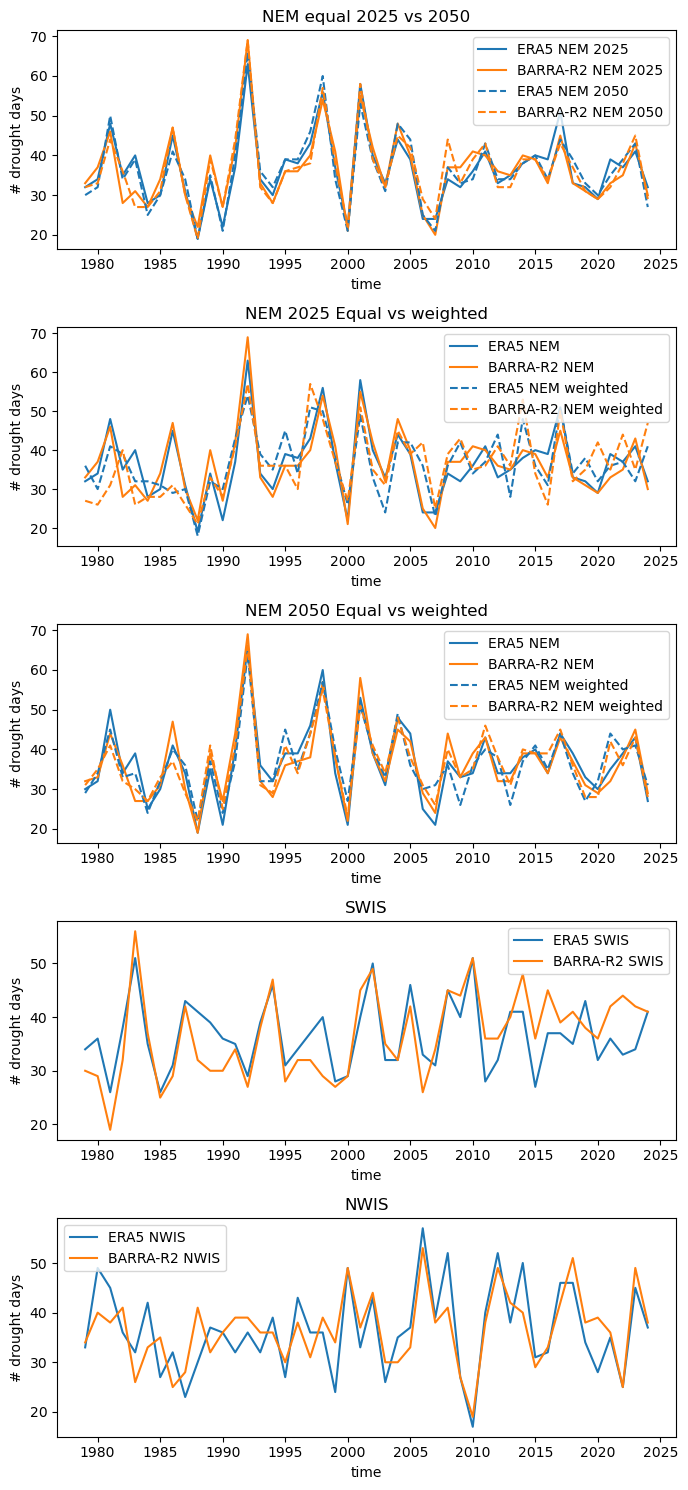

In [30]:
fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_drought_days(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_drought_days(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_drought_days(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="ERA5 SWIS")
n_drought_days(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_drought_days(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="ERA5 NWIS")
n_drought_days(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought days")

plt.tight_layout()

Number of drought periods per year

In [11]:
def n_droughts(da, min_len=1):
    """
    Return number of droughts of a minimum length per year
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(da >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return xr.where(diff == -1, 1, 0).resample(time="1YS").sum()

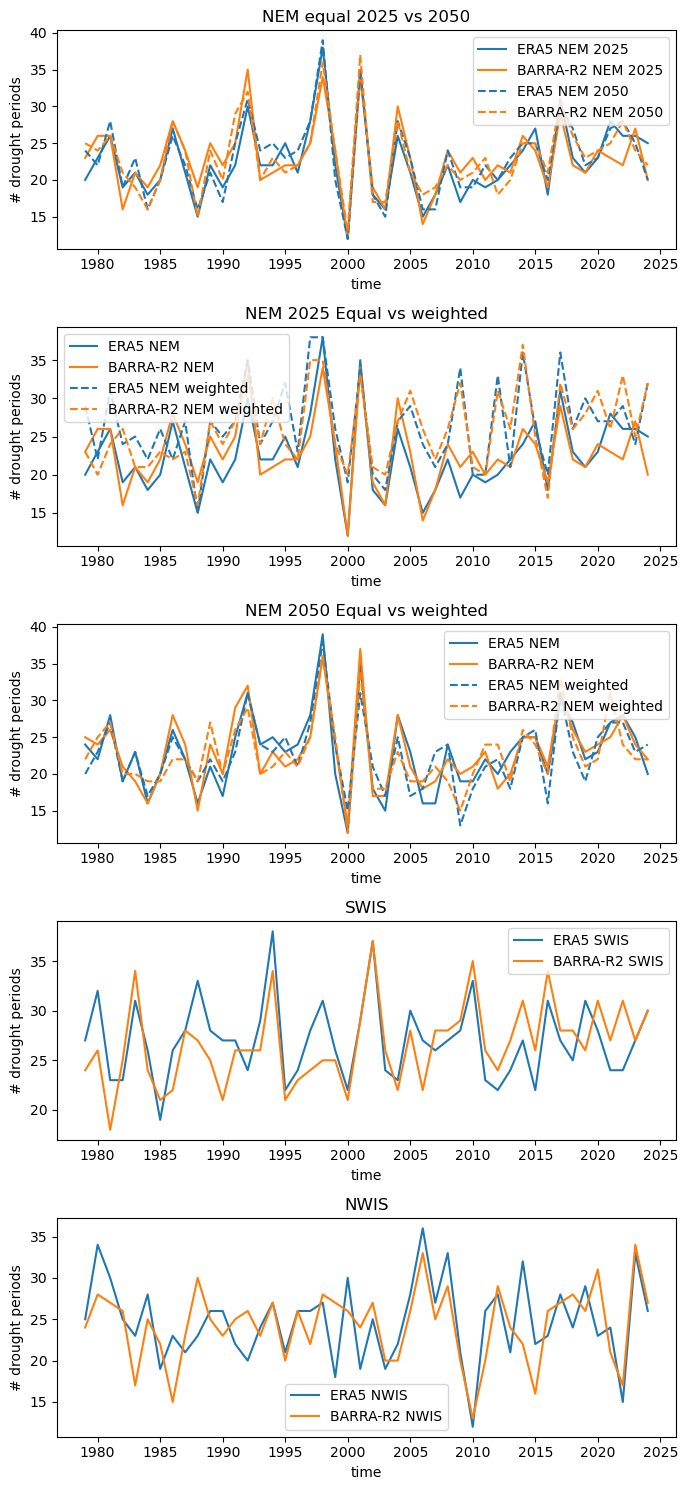

In [36]:
min_len = 1

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

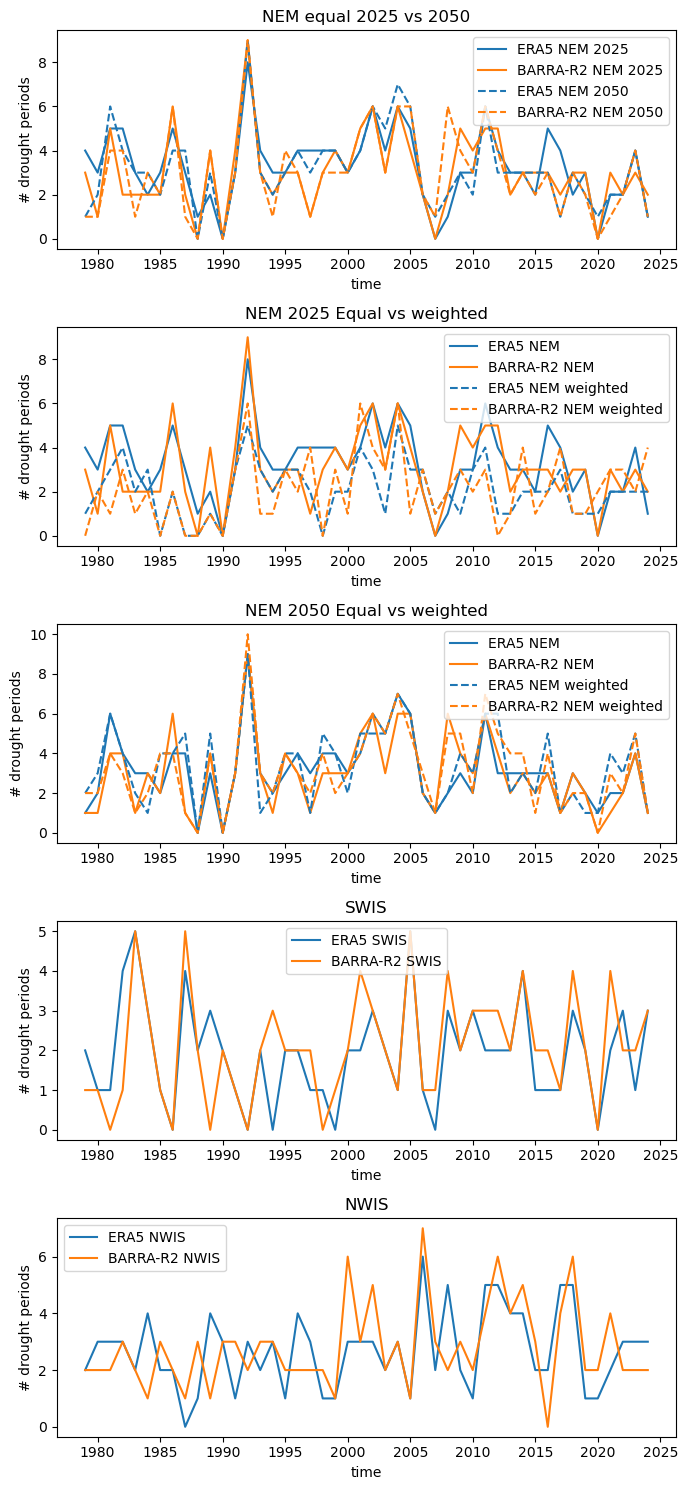

In [37]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

n_droughts(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
n_droughts(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

n_droughts(
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
n_droughts(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

n_droughts(
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
n_droughts(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("# drought periods")
    
plt.tight_layout()

Longest drought per year

In [12]:
def longest_drought(da):
    """
    Return longest drought each year
    """
    return da.groupby("time.year").max()

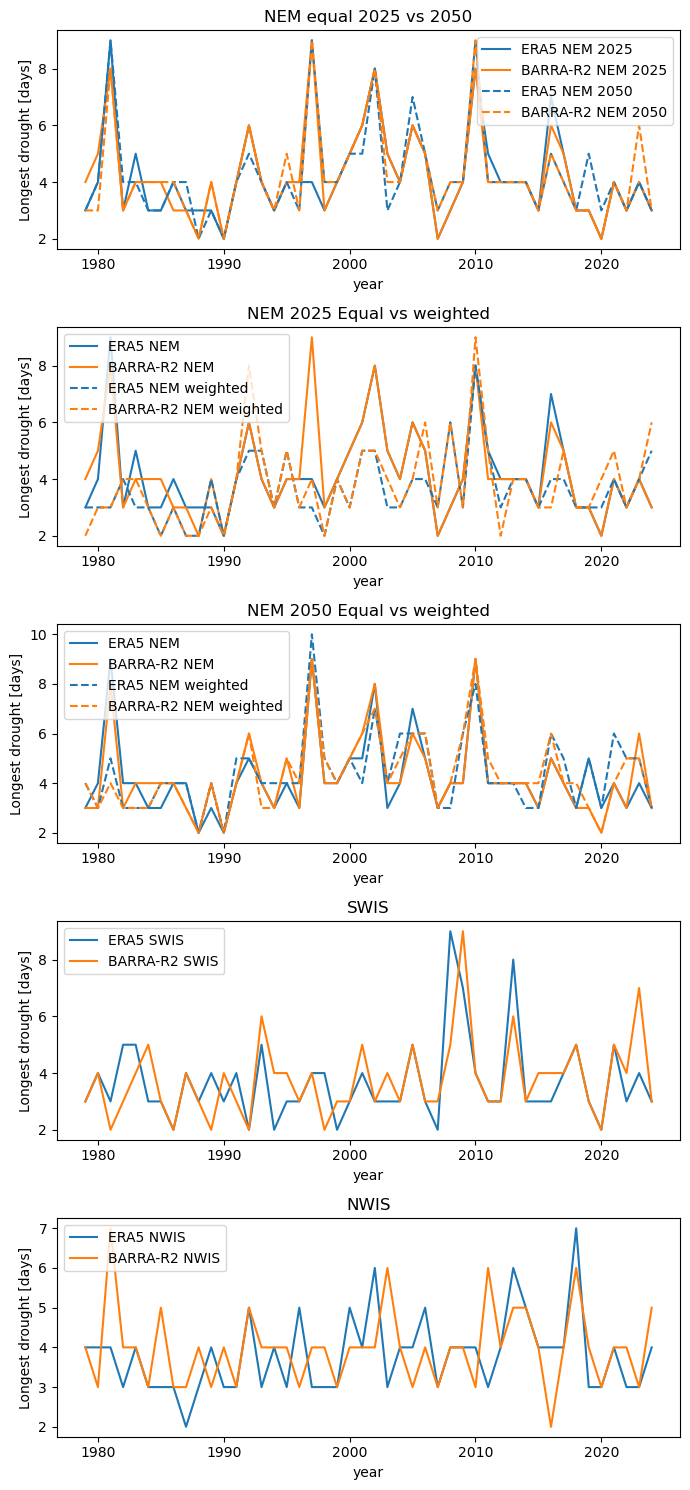

In [34]:
fig, ax = plt.subplots(5, 1, figsize=(7, 15))

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2025")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"]
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM")

longest_drought(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
longest_drought(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"]
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

longest_drought(
    ws_dict["ERA5_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="ERA5 SWIS")
longest_drought(
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"]
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

longest_drought(
    ws_dict["ERA5_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="ERA5 NWIS")
longest_drought(
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"]
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Longest drought [days]")
    
plt.tight_layout()

Accumulated drought intensity

In [13]:
def max_intensity(da, mask, min_len=1):
    """
    Return annual max of drought intensity

    da: array of accumulated wind speed anomalies on drought days
    mask: array of drought periods
    min_len: int, minimum number of consecutive drought days per drought period
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(mask >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return da.where(diff == -1).resample(time="1YS").min()

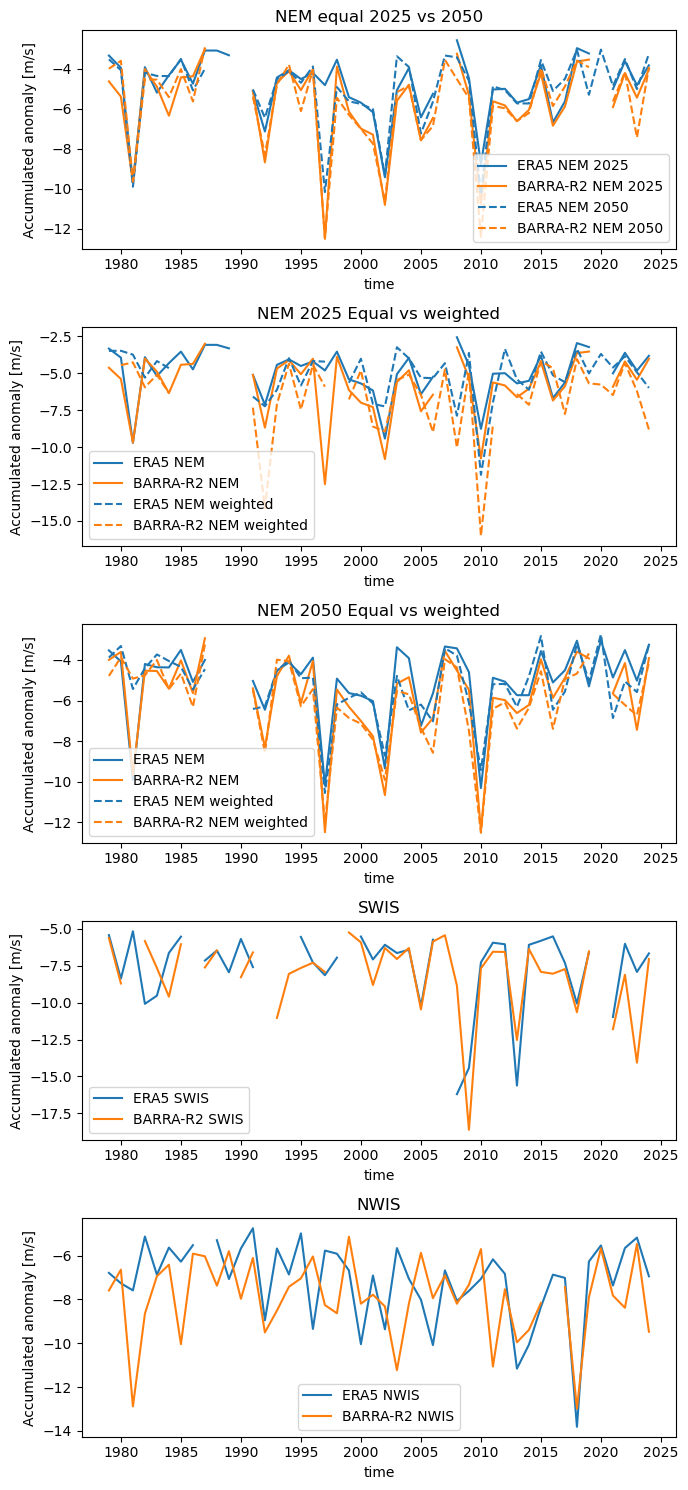

In [43]:
min_len = 3

fig, ax = plt.subplots(5, 1, figsize=(7, 15))

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2025")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2025")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="ERA5 NEM 2050", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[0], label="BARRA-R2 NEM 2050", color="tab:orange", ls="--")
ax[0].legend()
ax[0].set_title("NEM equal 2025 vs 2050")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[1], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[1].legend()
ax[1].set_title("NEM 2025 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM")

max_intensity(
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["ERA5_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="ERA5 NEM weighted", color="tab:blue", ls="--")
max_intensity(
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[2], label="BARRA-R2 NEM weighted", color="tab:orange", ls="--")
ax[2].legend()
ax[2].set_title("NEM 2050 Equal vs weighted")

max_intensity(
    ws_dict["ERA5_SWIS"]["drought_severity_p10"],
    ws_dict["ERA5_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="ERA5 SWIS")
max_intensity(
    ws_dict["BARRA-R2_SWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_SWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[3], label="BARRA-R2 SWIS")
ax[3].legend()
ax[3].set_title("SWIS")

max_intensity(
    ws_dict["ERA5_NWIS"]["drought_severity_p10"],
    ws_dict["ERA5_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="ERA5 NWIS")
max_intensity(
    ws_dict["BARRA-R2_NWIS"]["drought_severity_p10"],
    ws_dict["BARRA-R2_NWIS"]["drought_len_p10"],
    min_len=min_len
).plot(ax=ax[4], label="BARRA-R2 NWIS")
ax[4].legend()
ax[4].set_title("NWIS")

for a in ax:
    a.set_ylabel("Accumulated anomaly [m/s]")
    
plt.tight_layout()

### Intensity-duration-frequency (IDF) analysis

Alternatively to setting an arbitrary threshold, plot IDF curves to see impact of varying the wind speed threshold (intensity), rolling average period (duration) and return period (frequency).

In [23]:
def daily_to_annual_prob(p_daily, days_per_year=365):
    """
    Convert daily exceedance probability to annual exceedance probability.
    Assumes independence between days.
    """
    return 1 - (1 - p_daily)**days_per_year

def annual_prob_to_return_period(p_annual):
    """
    Convert annual exceedance probability to return period (in years).
    """
    return 1 / p_annual

def return_period_to_annual_prob(T):
    """
    Convert return period (years) to annual exceedance probability.
    """
    return 1 / T

def annual_to_daily_prob(p_annual, days_per_year=365):
    """
    Convert annual exceedance probability to daily exceedance probability.
    """
    return 1 - (1 - p_annual)**(1 / days_per_year)

def daily_prob_to_return_period(p_daily, days_per_year=365):
    """
    Convert daily exceedance probability directly to return period (years).
    """
    p_annual = daily_to_annual_prob(p_daily, days_per_year)
    return annual_prob_to_return_period(p_annual)

def return_period_to_daily_prob(T, days_per_year=365):
    """
    Convert return period (years) directly to daily exceedance probability.
    """
    p_annual = return_period_to_annual_prob(T)
    return annual_to_daily_prob(p_annual, days_per_year)

In [24]:
ws_roll_dict = {}
for k, v in ws_dict.items():
    var_name = list(v.data_vars)[0]
    # da = v[var_name].to_dataset(name=var_name)
    da = v[var_name].expand_dims({"window_len": [1]})
    
    da_list = [da]

    # for roll in [2, 3, 4, 5, 7, 10, 14, 21, 30]:
    for roll in range(2, 31):
        da_roll = da.rolling(time=roll).mean()
        # da[var_name+"_roll"+str(roll)] = da_roll
        da_roll = da_roll.assign_coords({"window_len": [roll]})
        da_list.append(da_roll)
    
    ws_roll_dict[k] = xr.concat(da_list, dim="window_len")

In [25]:
def drought_intensity(da, freq, dim="time"):
    da = da.dropna("time")
    return da.where(da < da.quantile(freq, "time")).max("time")

In [26]:
from matplotlib.lines import Line2D

In [27]:
def _idf_plot(
    ax,
    roll_da_list,
    q_freqs,
    legend_labels=None,
    ls_labels=None,
    colors=["tab:blue", "tab:orange", "tab:green", "tab:pink", "k", "tab:grey"]
):
    # fig, ax = plt.subplots(1, 1, figsize=(7,5))

    # markers = ["o", "s", "^", "v", "x", "d"]
    linestyles = ["-", "--"]
    
    for c, q in zip(
        colors,
        q_freqs
    ):  
        for da, ls in zip(roll_da_list, linestyles):
            ax.plot(
                da.window_len,
                drought_intensity(da, q),
                color=c,
                ls=ls,
                # label=str(q)
                )
    # Common legend
    if legend_labels is None:
        legend_labels = [str(np.round(q, 3)) for q in q_freqs]
    legend_colors = colors[:len(q_freqs)]
    legend_lines = [
        Line2D(
            [], [], color=legend_colors[i], linestyle=linestyles[0], label=legend_labels[i]
        ) for i in range(len(q_freqs))
    ]
    # ax.legend(handles=legend_lines, loc="lower right")
    
    # Legend for second set of data
    if len(roll_da_list) == 2:
        legend2_lines = [
            Line2D(
                [], [], color="gray", linestyle=linestyles[i], label=ls_labels[i]
            ) for i in range(2)
        ]
        legend_lines.append(legend2_lines[0])
        legend_lines.append(legend2_lines[1])
    ax.legend(handles=legend_lines, loc="lower right")

In [28]:
def plot_idf(roll_da_list, q_freqs, legend_labels=None, ls_labels=None):
    fig, ax = plt.subplots(1, 1, figsize=(7,5))
    _idf_plot(ax, roll_da_list, q_freqs, legend_labels, ls_labels)
        
    ax.set_xlabel("Duration [d]")
    ax.set_ylabel("Wind speed intensity [m/s]")
    ax.set_title("Intensity vs duration vs frequency")
    ax.set_yticks(np.arange(1, 3.1, 0.5))

In [29]:
def idf_surface_daily(roll_da, thresholds):
    """
    roll_da: rolling averaged daily values (DataArray with time and window_len dimension)
    thresholds: list/array of wind speed thresholds (m/s)
    """
    results = []

    for d in roll_da.window_len.values:
        # empirical CDF for each threshold
        probs = [(roll_da.sel(window_len=d) <= thr).mean().item() for thr in thresholds]
        results.append(probs)

    return xr.DataArray(
        np.array(results), 
        coords={"window_len": roll_da.window_len.values, "threshold": thresholds},
        dims=["window_len", "threshold"]
    )

In [30]:
def _add_contour(ax, roll_da, levels=[0.01, 0.05, 0.1], colors="white", ls="-", labels=None):
    cs = ax.contour(
        roll_da.window_len,
        roll_da.threshold,
        roll_da.T,
        levels=levels,
        colors=colors,
        linestyles=ls
    )
    if isinstance(labels, list):
        fmt = {}
        for l, s in zip(cs.levels, labels):
            fmt[l] = s
        ax.clabel(cs, fmt=fmt)
    elif labels is None:
        pass
    elif labels == "%":
        
        def fmt(x):
            s = f"{x*100:.1f}"
            if s.endswith("0"):
                s = f"{x*100:.0f}"
            return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"
        
        ax.clabel(cs, fmt=fmt)
    else:
        fmt="%.3f"
        ax.clabel(cs, fmt=fmt)

In [85]:
def plot_idf_surface(
    ax,
    roll_da_list,
    q_freqs,
    legend_labels=None,
    ls_labels=None,
    colors=["tab:blue", "tab:orange", "tab:green", "tab:pink", "k", "tab:grey"],
    extra_legend=False
):
    THRESHOLDS = np.arange(0, 5.1, 0.05)
    
    idf_surface = idf_surface_daily(
        roll_da_list[0],
        THRESHOLDS
    )
    idf_surface.plot(
        ax=ax,
        x="window_len",
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar_kwargs={"label": "Probability [-]"}
    )
    ax.set_xlim(1, 30)
    ax.set_xscale("log")
    # ax.set_xticks([1, 5, 10, 20, 30])
    
    _add_contour(
        ax,
        idf_surface,
        levels=q_freqs,
        colors=colors,
        labels=legend_labels
    )

    if extra_legend: # Custom legend for colored lines
        legend_lines2 = [
            Line2D(
                [], [], color=colors[i], linestyle="-", label='{:.1%}'.format(q_freqs[i])
            ) for i in range(len(q_freqs))
        ]
        
        legend = ax.legend(handles=legend_lines2, loc=(-0, -0.), ncols=4, facecolor="lightgray", fontsize=10)
        ax.add_artist(legend)

    if len(roll_da_list) == 2:
        idf_surface_2 = idf_surface_daily(
            roll_da_list[1],
            THRESHOLDS
        )
        
        _add_contour(
            ax,
            idf_surface_2,
            levels=q_freqs,
            colors=colors,
            labels=None,
            ls="--"
        )
        
        # Legend for ls
        linestyles = ["-", "--"]
        legend_lines = [
            Line2D(
                [], [], color="k", linestyle=linestyles[i], label=ls_labels[i]
            ) for i in range(2)
        ]
        ax.legend(handles=legend_lines, loc="lower right", fontsize=8)

In [77]:
rp_probs = return_period_to_daily_prob(np.array([3, 5, 10]))
rp_probs

array([0.00111025, 0.00061117, 0.00028862])

In [94]:
FREQUENCY_QUANTILES = np.append(
    np.array([0.05, 0.01, 1/365, 1/(365*3)]),
    rp_probs
)[:3]
# FREQUENCY_QUANTILES = rp_probs
FREQUENCY_QUANTILES

array([0.05      , 0.01      , 0.00273973])

In [95]:
daily_prob_to_return_period(FREQUENCY_QUANTILES)

array([1.00000001, 1.02618618, 1.58071508])

Text(0.5, 0, 'Averaging period [d]')

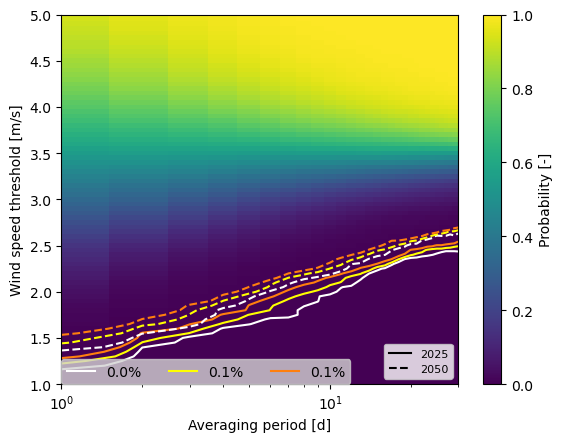

In [88]:
fig, ax = plt.subplots(1, 1)

plot_idf_surface(
    ax,
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["2025", "2050"],
    colors=["w", "yellow", "tab:orange", "tab:red"],
    # colors=["tab:pink"", "cyan", "tab:blue", "tab:green"]
    extra_legend=True
)

ax.set_ylim(1, 5)
ax.set_ylabel("Wind speed threshold [m/s]")
ax.set_xlabel("Averaging period [d]")

In [89]:
IDF_COLORS = ["w", "yellow", "tab:orange", "tab:red"]

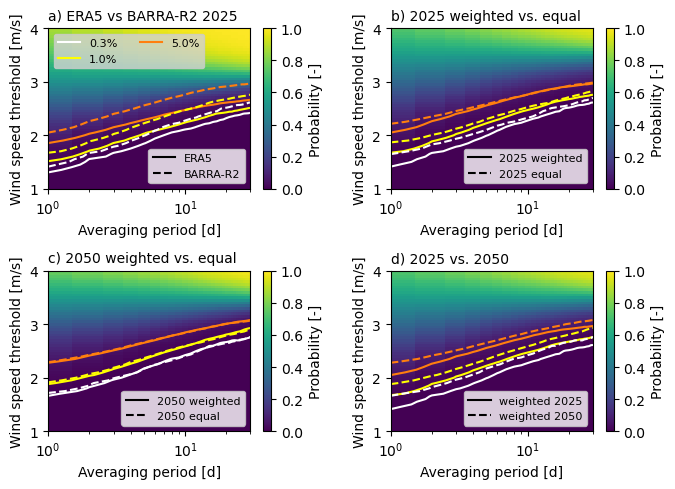

In [98]:
fig, ax = plt.subplots(2, 2, figsize=(7,5))

# rp_labels = ["3 yr", "5 yr", "10 yr"]
legend_lines2 = [
    Line2D(
        [], [], color=IDF_COLORS[i], linestyle="-", label='{:.1%}'.format(FREQUENCY_QUANTILES[::-1][i])
    ) for i in range(len(rp_labels))
]

legend = ax[0,0].legend(handles=legend_lines2, loc="upper left", ncols=2, facecolor="lightgray", fontsize=8)
ax[0,0].add_artist(legend)

# ERA5 vs BARRA-R2
plot_idf_surface(
    ax[0,0],
    [
        ws_roll_dict["ERA5_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["ERA5", "BARRA-R2"],
    colors=IDF_COLORS
)
ax[0,0].set_title("a) ERA5 vs BARRA-R2 2025", loc="left", fontsize=10)

# Weighted vs unweighted
plot_idf_surface(
    ax[0,1],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["2025 weighted", "2025 equal"],
    colors=IDF_COLORS
)
ax[0,1].set_title("b) 2025 weighted vs. equal", loc="left", fontsize=10)

# 2025 vs 2050 weighted
plot_idf_surface(
    ax[1,0],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["2050 weighted", "2050 equal"],
    colors=IDF_COLORS
)
ax[1,0].set_title("c) 2050 weighted vs. equal", loc="left", fontsize=10)

# 2025 vs 2050 weighted
plot_idf_surface(
    ax[1,1],
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]
    ],
    FREQUENCY_QUANTILES[:][::-1], # Need to be ascending so reverse
    legend_labels=None,
    ls_labels=["weighted 2025", "weighted 2050"],
    colors=IDF_COLORS
)
ax[1,1].set_title("d) 2025 vs. 2050", loc="left", fontsize=10)

for a in ax.flatten():
    a.set_ylim(1, 4)
    a.set_ylabel("Wind speed threshold [m/s]")
    a.set_xlabel("Averaging period [d]")

plt.tight_layout()

['tab:blue', 'tab:orange', 'tab:green', 'tab:pink', 'k', 'tab:grey']


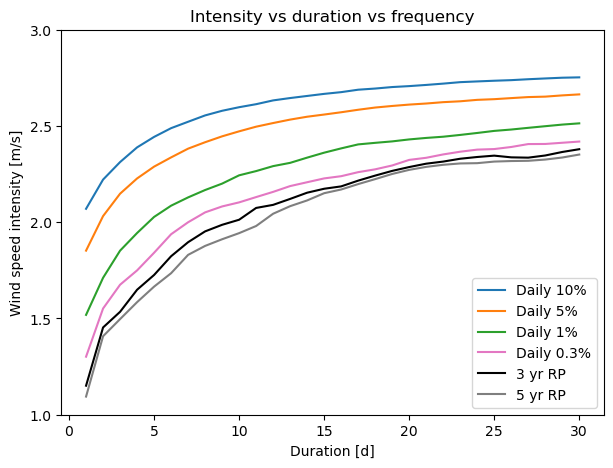

In [58]:
plot_idf(
    [ws_roll_dict["ERA5_NEM_NEM_wind_2025_weighted"]],
    FREQUENCY_QUANTILES,
    legend_labels=["Daily 10%", "Daily 5%", "Daily 1%", "Daily 0.3%", "3 yr RP", "5 yr RP"]
)

['tab:blue', 'tab:orange', 'tab:green', 'tab:pink', 'k', 'tab:grey']


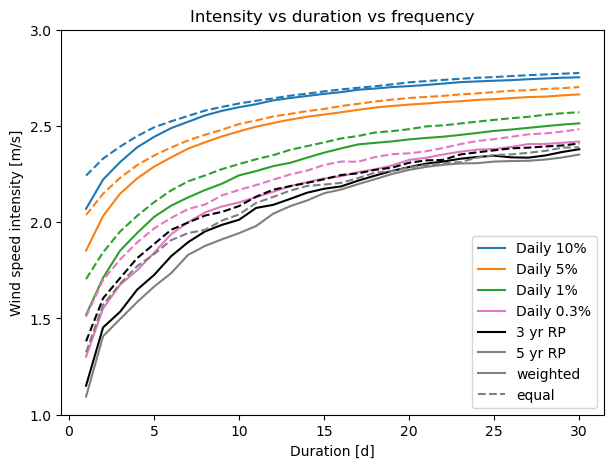

In [59]:
plot_idf(
    [
        ws_roll_dict["ERA5_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["ERA5_NEM_NEM_wind_2025_unweighted"]
    ],
    FREQUENCY_QUANTILES,
    legend_labels=["Daily 10%", "Daily 5%", "Daily 1%", "Daily 0.3%", "3 yr RP", "5 yr RP"],
    ls_labels=["weighted", "equal"]
)

['tab:blue', 'tab:orange', 'tab:green', 'tab:pink']


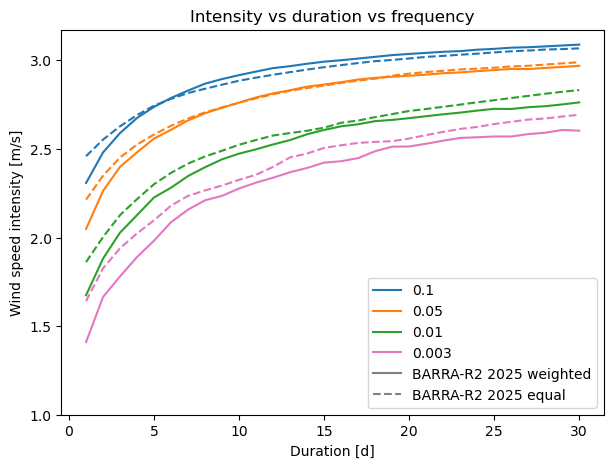

In [62]:
plot_idf(
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_unweighted"]
    ],
    FREQUENCY_QUANTILES[:4],
    ls_labels=["BARRA-R2 2025 weighted", "BARRA-R2 2025 equal"]
)

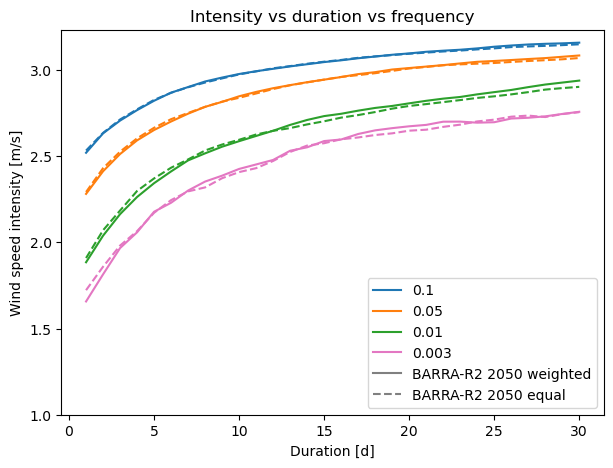

In [23]:
plot_idf(
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_unweighted"]
    ],
    FREQUENCY_QUANTILES[:4],
    ls_labels=["BARRA-R2 2050 weighted", "BARRA-R2 2050 equal"]
)

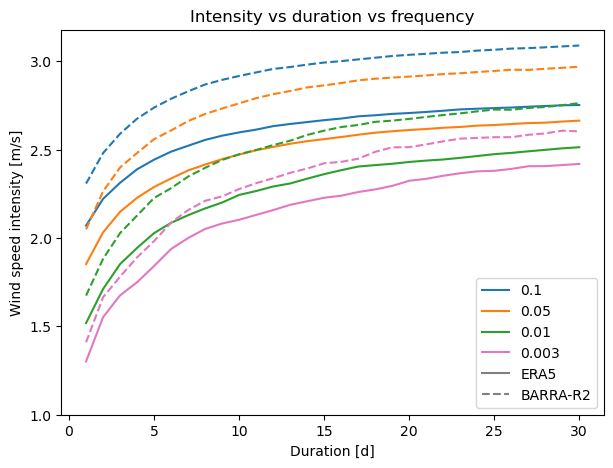

In [25]:
plot_idf(
    [
        ws_roll_dict["ERA5_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"]
    ],
    FREQUENCY_QUANTILES[:4],
    # legend_labels=["Daily 10%", "Daily 5%", "Daily 1%", "3 yr RP", "5 yr RP", "10 yr RP"],
    ls_labels=["ERA5", "BARRA-R2"]
)

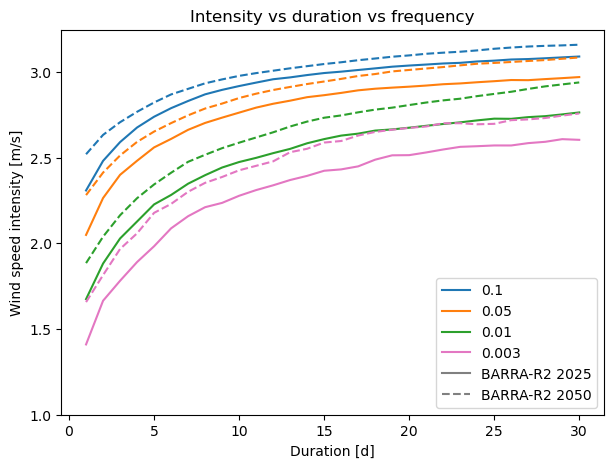

In [70]:
plot_idf(
    [
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2025_weighted"],
        ws_roll_dict["BARRA-R2_NEM_NEM_wind_2050_weighted"]
    ],
    FREQUENCY_QUANTILES[:4],
    ls_labels=["BARRA-R2 2025", "BARRA-R2 2050"]
)

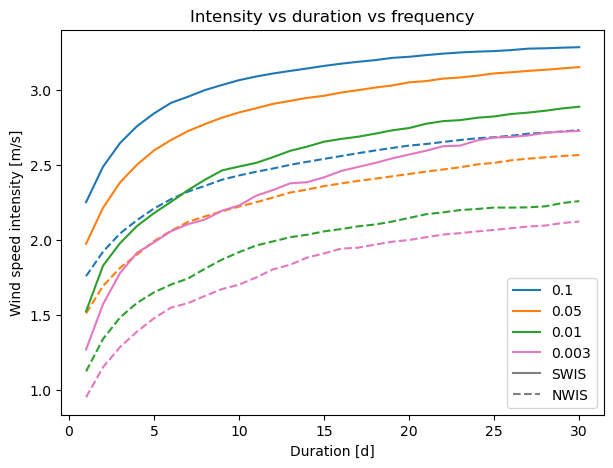

In [72]:
plot_idf(
    [
        ws_roll_dict["BARRA-R2_SWIS"],
        ws_roll_dict["BARRA-R2_NWIS"]
    ],
    FREQUENCY_QUANTILES[:4],
    ls_labels=["SWIS", "NWIS"]
)